<a href="https://colab.research.google.com/github/albert-magarire/Data-Science-and-ML/blob/main/HoverNet_MultiDataset_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HoVer-Net: Multi-Dataset Testing Notebook
# MoNuSeg-Trained Model → CoNSeP, TNBC, CPM

This notebook evaluates a HoVer-Net model (trained on MoNuSeg) against three
external test datasets. **No retraining** — inference and metrics only.

**Metrics computed:**
- **Pixel-level:** Dice, Jaccard (IoU), Precision, Recall, Specificity, Accuracy
- **Instance-level:** Panoptic Quality (PQ), Segmentation Quality (SQ), Recognition Quality (RQ), Aggregated Jaccard Index (AJI), Detection F1/Precision/Recall

In [1]:
from google.colab import drive
import os

try:
    drive.flush_and_unmount()
except ValueError:
    pass

if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
    try:
        os.rmdir('/content/drive')
    except OSError:
        import shutil
        shutil.rmtree('/content/drive')

drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [2]:
import subprocess, sys, os

for pkg in ['imgaug==0.4.0', 'tensorboardX', 'docopt', 'termcolor',
            'scikit-image', 'scikit-learn', 'scipy', 'tqdm',
            'opencv-python-headless']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'])

REPO_PATH = '/content/hover_net'
if not os.path.isdir(REPO_PATH):
    os.system(f'git clone https://github.com/vqdang/hover_net.git {REPO_PATH}')

import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [3]:
import os

REPO_PATH = '/content/hover_net'

# Model settings (must match training)
MODEL_MODE          = 'fast'       # 'fast' for MoNuSeg/PanNuke/MoNuSAC
TYPE_CLASSIFICATION = False
NR_TYPES            = None

CHECKPOINT_PATH = '/content/drive/MyDrive/hovernet_checkpoints/phase2_best.tar'

# Option B: If you know the exact best epoch from FINAL_evaluation_cell output,
# uncomment and set:
# CHECKPOINT_PATH = '/content/hovernet_logs/01/net_epoch=XX.tar'

# Test datasets
TEST_DATASETS = {
    'CoNSeP': '/content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/CoNSeP_Combined',
    'TNBC':   '/content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/TNBC_Processed',
    'CPM':    '/content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/Combined_CPM',
}

# Patch extraction settings (must match training)
WIN_SIZE  = [540, 540]
STEP_SIZE = [164, 164]

# Output directory for predictions
OUTPUT_ROOT = '/content/hovernet_test_results'

print('Configuration loaded.')
print(f'  Checkpoint: {CHECKPOINT_PATH}')
print(f'  Model mode: {MODEL_MODE}')
for name, path in TEST_DATASETS.items():
    exists = os.path.isdir(path)
    print(f'  {name}: {path} {"✓" if exists else "✗ NOT FOUND"}'  )

Configuration loaded.
  Checkpoint: /content/drive/MyDrive/hovernet_checkpoints/phase2_best.tar
  Model mode: fast
  CoNSeP: /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/CoNSeP_Combined ✓
  TNBC: /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/TNBC_Processed ✓
  CPM: /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/Combined_CPM ✓


In [4]:
import os, sys, importlib, numpy as np

sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH)

# --- Patch np.lib.pad → np.pad ---
pe_path = os.path.join(REPO_PATH, 'misc/patch_extractor.py')
if os.path.exists(pe_path):
    with open(pe_path, 'r') as f:
        code = f.read()
    if 'np.lib.pad' in code:
        with open(pe_path, 'w') as f:
            f.write(code.replace('np.lib.pad', 'np.pad'))
        print('Patched: np.lib.pad -> np.pad')

# --- Patch np.sctypes for imgaug ---
if not hasattr(np, 'sctypes'):
    np.sctypes = {
        'float': [np.float16, np.float32, np.float64],
        'int': [np.int8, np.int16, np.int32, np.int64],
        'uint': [np.uint8, np.uint16, np.uint32, np.uint64],
        'complex': [np.complex64, np.complex128]
    }
    if hasattr(np, 'float128'):
        np.sctypes['float'].append(np.float128)
    print('Patched: np.sctypes for imgaug')

# --- Patch viz_step_output shape alignment ---
rd_path = os.path.join(REPO_PATH, 'models/hovernet/run_desc.py')
if os.path.exists(rd_path):
    with open(rd_path, 'r') as f:
        code = f.read()
    old_line = "aligned_shape = np.min(np.array(aligned_shape), axis=0)[1:3]"
    if old_line in code:
        new_logic = (
            "    shapes = [imgs.shape, true_np.shape, pred_np.shape]\n"
            "    min_h = min(s[1] for s in shapes)\n"
            "    min_w = min(s[2] for s in shapes)\n"
            "    aligned_shape = [min_h, min_w]"
        )
        code = code.replace(
            "aligned_shape = np.min(np.array(aligned_shape), axis=0)[1:3]",
            new_logic
        )
        with open(rd_path, 'w') as f:
            f.write(code)
        print('Patched: viz_step_output shape alignment')

# --- Patch np.int deprecation ---
for subdir in ['models/hovernet', 'dataloader', 'misc', 'metrics', 'run_utils']:
    full = os.path.join(REPO_PATH, subdir)
    if not os.path.isdir(full):
        continue
    for fname in os.listdir(full):
        if not fname.endswith('.py'):
            continue
        fpath = os.path.join(full, fname)
        with open(fpath, 'r') as f:
            txt = f.read()
        changed = False
        for old, new in [('np.int,', 'int,'), ('np.int)', 'int)'),
                         ('np.float,', 'float,'), ('np.float)', 'float)'),
                         ('np.bool,', 'bool,'), ('np.bool)', 'bool)')]:
            if old in txt:
                txt = txt.replace(old, new)
                changed = True
        if changed:
            with open(fpath, 'w') as f:
                f.write(txt)

print('All patches applied.')

Patched: np.lib.pad -> np.pad
Patched: np.sctypes for imgaug
Patched: viz_step_output shape alignment
All patches applied.


In [5]:
import os, glob

print('=' * 70)
print('  DATASET STRUCTURE EXPLORATION')
print('=' * 70)

IMG_EXTENSIONS = ['.png', '.jpg', '.jpeg', '.tiff', '.tif', '.bmp']

for name, base_path in TEST_DATASETS.items():
    print(f'\n--- {name} ({base_path}) ---')
    if not os.path.isdir(base_path):
        print('  ✗ Directory not found!')
        continue

    # List top-level contents
    contents = sorted(os.listdir(base_path))
    print(f'  Contents: {contents}')

    # Try to find images and masks directories
    for subdir in contents:
        full = os.path.join(base_path, subdir)
        if os.path.isdir(full):
            files = os.listdir(full)
            img_files = [f for f in files
                         if any(f.lower().endswith(ext) for ext in IMG_EXTENSIONS)]
            npy_files = [f for f in files if f.endswith('.npy')]
            mat_files = [f for f in files if f.endswith('.mat')]
            print(f'    {subdir}/: {len(img_files)} images, '
                  f'{len(npy_files)} npy, {len(mat_files)} mat, '
                  f'{len(files)} total')
            if img_files:
                print(f'      Sample: {img_files[:3]}')
        else:
            ext = os.path.splitext(subdir)[1].lower()
            if ext in IMG_EXTENSIONS + ['.npy', '.mat']:
                pass  # files at root level

    # Also check if images/masks are at root level
    root_imgs = [f for f in contents
                 if any(f.lower().endswith(ext) for ext in IMG_EXTENSIONS)]
    if root_imgs:
        print(f'  Root-level image files: {len(root_imgs)}')
        print(f'    Sample: {root_imgs[:3]}')

  DATASET STRUCTURE EXPLORATION

--- CoNSeP (/content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/CoNSeP_Combined) ---
  Contents: ['images', 'masks']
    images/: 41 images, 0 npy, 0 mat, 41 total
      Sample: ['test_10.png', 'test_1.png', 'test_13.png']
    masks/: 41 images, 0 npy, 0 mat, 41 total
      Sample: ['test_5.png', 'test_10.png', 'test_13.png']

--- TNBC (/content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/TNBC_Processed) ---
  Contents: ['images', 'masks']
    images/: 50 images, 0 npy, 0 mat, 50 total
      Sample: ['01_2.png', '01_4.png', '01_3.png']
    masks/: 50 images, 0 npy, 0 mat, 50 total
      Sample: ['01_3.png', '01_2.png', '01_1.png']

--- CPM (/content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/Combined_CPM) ---
  Contents: ['images', 'masks']
    images/: 79 images, 0 npy, 0 mat, 79 total
      Sample: ['image_02.png', 'image_04.png', 'image_01.png']
    masks/: 79 images, 0 npy, 0 mat, 79 t

In [9]:
import glob, pathlib, shutil, warnings, cv2, numpy as np
from scipy import ndimage
from scipy.ndimage import label as nd_label
from skimage.segmentation import watershed
import tqdm, torch, torch.nn.functional as F
from torch.utils.data import DataLoader

sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH)

from misc.patch_extractor import PatchExtractor
from dataloader.train_loader import FileLoader
from models.hovernet.net_desc import create_model
from models.hovernet.targets import gen_targets

device = 'cuda' if torch.cuda.is_available() else 'cpu'

if MODEL_MODE == 'original':
    act_shape, out_shape = [270, 270], [80, 80]
else:
    act_shape, out_shape = [256, 256], [164, 164]

IMG_EXTENSIONS = ['.png', '.jpg', '.jpeg', '.tiff', '.tif', '.bmp']


def load_instance_mask(mask_path):
    """Load a mask image and ensure it has instance labels (not binary)."""
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if mask is None:
        return None
    if mask.ndim == 3:
        if mask.shape[2] == 4:
            mask = mask[:, :, 0]
        elif mask.shape[2] == 3:
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        else:
            mask = mask[:, :, 0]
    mask = mask.astype(np.int32)
    unique_vals = np.unique(mask)
    non_bg = unique_vals[unique_vals != 0]
    # If mask appears binary, run connected components to get instance labels
    if len(non_bg) <= 1:
        binary = (mask > 0).astype(np.uint8)
        labeled, _ = ndimage.label(binary)
        mask = labeled.astype(np.int32)
    return mask


def find_mask_path(img_stem, mask_dir):
    """Find the corresponding mask file for a given image stem."""
    candidates = [
        img_stem,
        img_stem + '_mask',
        img_stem + '_label',
        img_stem + '_anno',
        img_stem + '_seg',
    ]
    for base in candidates:
        for ext in IMG_EXTENSIONS:
            for e in [ext, ext.upper()]:
                path = os.path.join(mask_dir, base + e)
                if os.path.exists(path):
                    return path
    return None


def extract_patches_for_dataset(dataset_name, base_path, patch_dir):
    """Extract 540x540 patches from a dataset with images/ and masks/ subdirs."""
    if os.path.isdir(patch_dir):
        shutil.rmtree(patch_dir)
    os.makedirs(patch_dir)

    # Auto-detect directory structure
    contents = os.listdir(base_path)
    subdirs = [d for d in contents if os.path.isdir(os.path.join(base_path, d))]
    subdir_lower = {d.lower(): d for d in subdirs}

    # Find image directory
    img_dir = None
    for candidate in ['images', 'image', 'imgs', 'img']:
        if candidate in subdir_lower:
            img_dir = os.path.join(base_path, subdir_lower[candidate])
            break
    if img_dir is None:
        # Maybe images are at root level
        root_imgs = [f for f in contents
                     if any(f.lower().endswith(ext) for ext in IMG_EXTENSIONS)]
        if root_imgs:
            img_dir = base_path
            print(f'  Using root directory for images')

    # Find mask directory
    mask_dir = None
    for candidate in ['masks', 'mask', 'labels', 'label', 'annotations',
                       'annotation', 'segmentation', 'seg', 'gt']:
        if candidate in subdir_lower:
            mask_dir = os.path.join(base_path, subdir_lower[candidate])
            break

    if img_dir is None:
        print(f'  ✗ Could not find image directory in {base_path}')
        print(f'    Subdirectories found: {subdirs}')
        return 0
    if mask_dir is None:
        print(f'  ✗ Could not find mask directory in {base_path}')
        print(f'    Subdirectories found: {subdirs}')
        return 0

    print(f'  Image dir: {img_dir}')
    print(f'  Mask dir:  {mask_dir}')

    # Collect image files
    img_files = []
    for ext in IMG_EXTENSIONS:
        img_files += glob.glob(os.path.join(img_dir, f'*{ext}'))
        img_files += glob.glob(os.path.join(img_dir, f'*{ext.upper()}'))
    img_files = sorted(set(img_files))
    print(f'  Found {len(img_files)} images')

    if len(img_files) == 0:
        return 0

    # Extract patches
    xtractor = PatchExtractor(WIN_SIZE, STEP_SIZE)
    total_patches, skipped, no_mask = 0, 0, 0

    for img_path in tqdm.tqdm(img_files, desc=f'  Extracting {dataset_name}'):
        stem = pathlib.Path(img_path).stem
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            skipped += 1
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        mask_path = find_mask_path(stem, mask_dir)
        if mask_path is None:
            no_mask += 1
            continue

        inst_map = load_instance_mask(mask_path)
        if inst_map is None:
            skipped += 1
            continue

        if img_rgb.shape[:2] != inst_map.shape[:2]:
            inst_map = cv2.resize(inst_map, (img_rgb.shape[1], img_rgb.shape[0]),
                                  interpolation=cv2.INTER_NEAREST).astype(np.int32)

        stacked = np.concatenate([img_rgb, inst_map[:, :, np.newaxis]], axis=-1)
        patches = xtractor.extract(stacked, 'mirror')
        for idx, patch in enumerate(patches):
            np.save(os.path.join(patch_dir, f'{stem}_{idx:04d}.npy'), patch)
        total_patches += len(patches)

    print(f'  → {total_patches} patches from {len(img_files)} images '
          f'({skipped} load errors, {no_mask} missing masks)')
    return total_patches


def pixel_metrics(gt_bin, pred_bin):
    """Compute pixel-level binary segmentation metrics."""
    gt = gt_bin.astype(np.uint8).flatten()
    pr = pred_bin.astype(np.uint8).flatten()
    TP = int(np.sum(pr & gt))
    TN = int(np.sum((1 - pr) & (1 - gt)))
    FP = int(np.sum(pr & (1 - gt)))
    FN = int(np.sum((1 - pr) & gt))
    safe = lambda n, d: float(n) / float(d) if d > 0 else 0.0
    return {
        'Dice': safe(2 * TP, 2 * TP + FP + FN),
        'Jac':  safe(TP, TP + FP + FN),
        'Prec': safe(TP, TP + FP),
        'Rec':  safe(TP, TP + FN),
        'Spec': safe(TN, TN + FP),
        'Acc':  safe(TP + TN, TP + TN + FP + FN),
    }


def compute_aji(gt_inst, pred_inst):
    """Aggregated Jaccard Index (AJI)."""
    gt_ids = [g for g in np.unique(gt_inst) if g > 0]
    pred_ids = [p for p in np.unique(pred_inst) if p > 0]
    if not gt_ids and not pred_ids:
        return 1.0
    if not gt_ids or not pred_ids:
        return 0.0
    overall_inter, overall_union, matched_pred = 0.0, 0.0, set()
    for g_id in gt_ids:
        g_mask = (gt_inst == g_id)
        best_iou, best_inter, best_union, best_pid = 0, 0, 0, None
        for p_id in pred_ids:
            inter = int(np.sum(g_mask & (pred_inst == p_id)))
            if inter == 0:
                continue
            union = int(np.sum(g_mask | (pred_inst == p_id)))
            iou = inter / union
            if iou > best_iou:
                best_iou, best_inter, best_union, best_pid = iou, inter, union, p_id
        if best_pid is not None:
            overall_inter += best_inter
            overall_union += best_union
            matched_pred.add(best_pid)
        else:
            overall_union += int(np.sum(g_mask))
    for p_id in pred_ids:
        if p_id not in matched_pred:
            overall_union += int(np.sum(pred_inst == p_id))
    return overall_inter / (overall_union + 1e-8)


def compute_pq(gt_inst, pred_inst, iou_thresh=0.5):
    """Panoptic Quality = SQ × RQ."""
    gt_ids = [g for g in np.unique(gt_inst) if g > 0]
    pred_ids = [p for p in np.unique(pred_inst) if p > 0]
    if not gt_ids and not pred_ids:
        return 1.0, 1.0, 1.0
    matched_ious, matched_gt, matched_pred = [], set(), set()
    for g_id in gt_ids:
        g_mask = (gt_inst == g_id)
        best_iou, best_pid = 0, None
        for p_id in pred_ids:
            if p_id in matched_pred:
                continue
            inter = int(np.sum(g_mask & (pred_inst == p_id)))
            if inter == 0:
                continue
            union = int(np.sum(g_mask | (pred_inst == p_id)))
            iou = inter / union
            if iou > best_iou:
                best_iou, best_pid = iou, p_id
        if best_pid is not None and best_iou >= iou_thresh:
            matched_ious.append(best_iou)
            matched_gt.add(g_id)
            matched_pred.add(best_pid)
    TP = len(matched_ious)
    FP = len(pred_ids) - len(matched_pred)
    FN = len(gt_ids) - len(matched_gt)
    SQ = float(np.mean(matched_ious)) if matched_ious else 0.0
    RQ = TP / (TP + 0.5 * FP + 0.5 * FN + 1e-8)
    return SQ * RQ, SQ, RQ


def compute_det_f1(gt_inst, pred_inst, iou_thresh=0.5):
    """Detection-level F1 score."""
    gt_ids = [g for g in np.unique(gt_inst) if g > 0]
    pred_ids = [p for p in np.unique(pred_inst) if p > 0]
    matched_gt, TP = set(), 0
    for p_id in pred_ids:
        p_mask = (pred_inst == p_id)
        for g_id in gt_ids:
            if g_id in matched_gt:
                continue
            inter = int(np.sum(p_mask & (gt_inst == g_id)))
            if inter == 0:
                continue
            union = int(np.sum(p_mask | (gt_inst == g_id)))
            if inter / union >= iou_thresh:
                TP += 1
                matched_gt.add(g_id)
                break
    FP = len(pred_ids) - TP
    FN = len(gt_ids) - len(matched_gt)
    prec = TP / (TP + FP + 1e-8)
    rec = TP / (TP + FN + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    return f1, prec, rec


def hovernet_post_process(np_probs, hv_map, small_obj_size=10):
    """Post-process HoVer-Net NP + HV outputs into an instance map."""
    fg_mask = (np_probs > 0.5).astype(np.uint8)
    if fg_mask.sum() == 0:
        return np.zeros_like(fg_mask, dtype=np.int32)

    h_map = hv_map[..., 0]
    v_map = hv_map[..., 1]

    sobelh_h = cv2.Sobel(h_map, cv2.CV_64F, 1, 0, ksize=3)
    sobelv_h = cv2.Sobel(h_map, cv2.CV_64F, 0, 1, ksize=3)
    sobelh_v = cv2.Sobel(v_map, cv2.CV_64F, 1, 0, ksize=3)
    sobelv_v = cv2.Sobel(v_map, cv2.CV_64F, 0, 1, ksize=3)

    grad_h = np.sqrt(sobelh_h**2 + sobelv_h**2)
    grad_v = np.sqrt(sobelh_v**2 + sobelv_v**2)
    overall_grad = grad_h + grad_v
    overall_grad = 1.0 - (overall_grad / (overall_grad.max() + 1e-8))

    energy = overall_grad * fg_mask
    energy_thresh = (energy > 0.5).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    energy_eroded = cv2.morphologyEx(energy_thresh, cv2.MORPH_OPEN, kernel)

    markers, num_markers = nd_label(energy_eroded)
    markers[fg_mask == 0] = 0
    if num_markers == 0:
        return np.zeros_like(fg_mask, dtype=np.int32)

    dist = cv2.distanceTransform(fg_mask, cv2.DIST_L2, 5)
    inst_map = watershed(-dist, markers, mask=fg_mask)

    for inst_id in np.unique(inst_map):
        if inst_id == 0:
            continue
        if np.sum(inst_map == inst_id) < small_obj_size:
            inst_map[inst_map == inst_id] = 0

    unique_ids = np.unique(inst_map)
    unique_ids = unique_ids[unique_ids > 0]
    new_map = np.zeros_like(inst_map)
    for new_id, old_id in enumerate(unique_ids, 1):
        new_map[inst_map == old_id] = new_id
    return new_map


print('All functions defined.')

All functions defined.


In [10]:
print('=' * 60)
print('  LOADING MODEL')
print('=' * 60)

assert os.path.exists(CHECKPOINT_PATH), \
    f'Checkpoint not found: {CHECKPOINT_PATH}'

model = create_model(input_ch=3, nr_types=NR_TYPES, freeze=False, mode=MODEL_MODE)
ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')
sd = ckpt['desc']
sd = {k.replace('module.', ''): v for k, v in sd.items()}
missing, unexpected = model.load_state_dict(sd, strict=False)
model = model.to(device)
model.eval()

print(f'  Checkpoint: {CHECKPOINT_PATH}')
print(f'  Missing keys: {len(missing)}')
print(f'  Unexpected keys: {len(unexpected)}')

# Quick sanity check with random input
with torch.no_grad():
    dummy = torch.randn(1, 3, 256, 256).to(device) * 128 + 128  # ~[0, 255] range
    dummy_out = model(dummy)
    np_range = dummy_out['np'].max().item() - dummy_out['np'].min().item()
    hv_range = dummy_out['hv'].abs().max().item()
    print(f'  NP logit range on random input: {np_range:.2f}')
    print(f'  HV output max abs: {hv_range:.4f}')
    if np_range < 1.0:
        print('  ⚠️ WARNING: NP range is narrow — check checkpoint!')
    else:
        print('  ✓ Model outputs look healthy')

  LOADING MODEL
  Checkpoint: /content/drive/MyDrive/hovernet_checkpoints/phase2_best.tar
  Missing keys: 0
  Unexpected keys: 0
  NP logit range on random input: 11.75
  HV output max abs: 0.8044
  ✓ Model outputs look healthy


In [11]:
def evaluate_dataset(dataset_name, base_path, model, verbose=True):
    """
    Full pipeline: extract patches → run inference → compute metrics.
    Returns a dict of metric name → mean value.
    """
    print(f'\n{"=" * 70}')
    print(f'  EVALUATING: {dataset_name}')
    print(f'  Path: {base_path}')
    print(f'{"=" * 70}')

    if not os.path.isdir(base_path):
        print(f'  ✗ Directory not found! Skipping.')
        return None

    # --- Step 1: Extract patches ---
    patch_dir = os.path.join(OUTPUT_ROOT, f'{dataset_name}_patches')
    print(f'\n  Step 1: Extracting patches...')
    n_patches = extract_patches_for_dataset(dataset_name, base_path, patch_dir)
    if n_patches == 0:
        print(f'  ✗ No patches extracted! Skipping.')
        return None

    # --- Step 2: Verify patch quality ---
    sample_patches = sorted(glob.glob(os.path.join(patch_dir, '*.npy')))[:5]
    print(f'\n  Step 2: Verifying patches...')
    for fpath in sample_patches[:3]:
        data = np.load(fpath)
        inst = data[..., 3].astype(np.int32)
        unique_ids = np.unique(inst)
        n_nuclei = len(unique_ids) - 1
        max_id = unique_ids.max()
        print(f'    {os.path.basename(fpath)}: {n_nuclei} nuclei, max_id={max_id}')
        if max_id <= 1 and n_nuclei > 0:
            print(f'      ⚠️ Binary mask detected — connected components applied')

    # --- Step 3: Setup data loader ---
    file_list = sorted(glob.glob(os.path.join(patch_dir, '*.npy')))
    dataset = FileLoader(
        file_list, mode='valid', with_type=TYPE_CLASSIFICATION,
        setup_augmentor=True, input_shape=act_shape, mask_shape=out_shape,
        target_gen=(gen_targets, {})
    )
    loader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=0)

    # --- Step 4: Run inference + compute metrics ---
    print(f'\n  Step 3: Running inference on {len(file_list)} patches...')

    pix_acc = {k: [] for k in ['Dice', 'Jac', 'Prec', 'Rec', 'Spec', 'Acc']}
    inst_acc = {k: [] for k in ['AJI', 'PQ', 'SQ', 'RQ',
                                 'Det_F1', 'Det_Prec', 'Det_Rec',
                                 'N_gt', 'N_pred']}

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm.tqdm(loader, desc=f'  {dataset_name}')):
            imgs = batch['img'].permute(0, 3, 1, 2).to(device).type(torch.float32)
            true_np = batch['np_map'].numpy()
            output = model(imgs)

            # Pixel-level: NP branch softmax
            np_probs_batch = F.softmax(output['np'], dim=1)
            pred_fg = (np_probs_batch[:, 1] > 0.5).cpu().numpy().astype(np.uint8)

            # Instance-level: NP probs + HV maps
            np_probs_np = np_probs_batch[:, 1].cpu().numpy()
            hv_maps = output['hv'].permute(0, 2, 3, 1).cpu().numpy()

            # Handle shape mismatch
            if pred_fg.shape[1:] != true_np.shape[1:]:
                min_h = min(pred_fg.shape[1], true_np.shape[1])
                min_w = min(pred_fg.shape[2], true_np.shape[2])
                pred_fg = pred_fg[:, :min_h, :min_w]
                true_np = true_np[:, :min_h, :min_w]
                np_probs_np = np_probs_np[:, :min_h, :min_w]
                hv_maps = hv_maps[:, :min_h, :min_w]

            for i in range(len(true_np)):
                # Pixel-level metrics
                gt_bin = (true_np[i] > 0).astype(np.uint8)
                m = pixel_metrics(gt_bin, pred_fg[i])
                for k, v in m.items():
                    pix_acc[k].append(v)

                # Instance-level metrics
                pred_inst = hovernet_post_process(np_probs_np[i], hv_maps[i])

                global_idx = batch_idx * loader.batch_size + i
                if global_idx < len(file_list):
                    raw_patch = np.load(file_list[global_idx])
                    gt_inst_full = raw_patch[..., 3].astype(np.int32)
                    ph, pw = pred_inst.shape
                    gh, gw = gt_inst_full.shape
                    y0, x0 = (gh - ph) // 2, (gw - pw) // 2
                    gt_inst = gt_inst_full[y0:y0+ph, x0:x0+pw]

                    aji = compute_aji(gt_inst, pred_inst)
                    pq, sq, rq = compute_pq(gt_inst, pred_inst)
                    f1, prec, rec = compute_det_f1(gt_inst, pred_inst)

                    inst_acc['AJI'].append(aji)
                    inst_acc['PQ'].append(pq)
                    inst_acc['SQ'].append(sq)
                    inst_acc['RQ'].append(rq)
                    inst_acc['Det_F1'].append(f1)
                    inst_acc['Det_Prec'].append(prec)
                    inst_acc['Det_Rec'].append(rec)
                    inst_acc['N_gt'].append(len(np.unique(gt_inst)) - 1)
                    inst_acc['N_pred'].append(len(np.unique(pred_inst)) - 1)

    # --- Compile results ---
    results = {}
    for k, v in pix_acc.items():
        results[k] = np.mean(v) if v else 0.0
    for k, v in inst_acc.items():
        results[k] = np.mean(v) if v else 0.0

    # --- Print results ---
    print(f'\n  {"─" * 50}')
    print(f'  {dataset_name} RESULTS ({len(file_list)} patches)')
    print(f'  {"─" * 50}')
    print(f'  Pixel-level:')
    for k in ['Dice', 'Jac', 'Prec', 'Rec', 'Spec', 'Acc']:
        print(f'    {k:<12}: {results[k]:.4f}')
    print(f'  Instance-level:')
    for k in ['PQ', 'SQ', 'RQ', 'AJI', 'Det_F1', 'Det_Prec', 'Det_Rec']:
        print(f'    {k:<12}: {results[k]:.4f}')
    print(f'  Avg nuclei — GT: {results["N_gt"]:.1f}  Pred: {results["N_pred"]:.1f}')
    print(f'  {"─" * 50}')

    return results


print('Evaluation function ready.')

Evaluation function ready.


In [12]:
import time

os.makedirs(OUTPUT_ROOT, exist_ok=True)

all_results = {}

for name, path in TEST_DATASETS.items():
    t0 = time.time()
    results = evaluate_dataset(name, path, model)
    elapsed = time.time() - t0
    if results is not None:
        all_results[name] = results
        print(f'  Completed in {elapsed/60:.1f} min')
    else:
        print(f'  ✗ {name} failed')

print(f'\n\nAll evaluations complete. {len(all_results)}/{len(TEST_DATASETS)} succeeded.')


  EVALUATING: CoNSeP
  Path: /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/CoNSeP_Combined

  Step 1: Extracting patches...
  Image dir: /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/CoNSeP_Combined/images
  Mask dir:  /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/CoNSeP_Combined/masks
  Found 41 images


  Extracting CoNSeP: 100%|██████████| 41/41 [02:26<00:00,  3.57s/it]


  → 2009 patches from 41 images (0 load errors, 0 missing masks)

  Step 2: Verifying patches...
    test_10_0000.npy: 70 nuclei, max_id=174
    test_10_0001.npy: 109 nuclei, max_id=174
    test_10_0002.npy: 104 nuclei, max_id=173

  Step 3: Running inference on 2009 patches...


  CoNSeP:  88%|████████▊ | 221/252 [00:44<00:03,  8.46it/s]/content/hover_net/models/hovernet/targets.py:33: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  crop_ann = morph.remove_small_objects(crop_ann, min_size=30)
  CoNSeP: 100%|██████████| 252/252 [00:50<00:00,  4.99it/s]



  ──────────────────────────────────────────────────
  CoNSeP RESULTS (2009 patches)
  ──────────────────────────────────────────────────
  Pixel-level:
    Dice        : 0.6191
    Jac         : 0.4966
    Prec        : 0.5971
    Rec         : 0.7199
    Spec        : 0.9072
    Acc         : 0.8967
  Instance-level:
    PQ          : 0.3656
    SQ          : 0.6807
    RQ          : 0.4757
    AJI         : 0.4017
    Det_F1      : 0.4329
    Det_Prec    : 0.4257
    Det_Rec     : 0.4726
  Avg nuclei — GT: 12.8  Pred: 14.1
  ──────────────────────────────────────────────────
  Completed in 3.3 min

  EVALUATING: TNBC
  Path: /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/TNBC_Processed

  Step 1: Extracting patches...
  Image dir: /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/TNBC_Processed/images
  Mask dir:  /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/TNBC_Processed/masks
  Found 50 images


...


  ──────────────────────────────────────────────────
  TNBC RESULTS (800 patches)
  ──────────────────────────────────────────────────
  Pixel-level:
    Dice        : 0.6508
    Jac         : 0.5370
    Prec        : 0.7810
    Rec         : 0.6005
    Spec        : 0.9777
    Acc         : 0.9513
  Instance-level:
    PQ          : 0.4866
    SQ          : 0.7153
    RQ          : 0.6086
    AJI         : 0.5364
    Det_F1      : 0.5236
    Det_Prec    : 0.5712
    Det_Rec     : 0.5076
  Avg nuclei — GT: 9.9  Pred: 8.7
  ──────────────────────────────────────────────────
  Completed in 2.3 min

  EVALUATING: CPM
  Path: /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/Combined_CPM

  Step 1: Extracting patches...
  Image dir: /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/Combined_CPM/images
  Mask dir:  /content/drive/MyDrive/Data_jiacheng/Full_test_dataset_On_MoNuSeg_Trained/Combined_CPM/masks
  Found 79 images


  Extracting CPM: 100%|██████████| 79/79 [03:15<00:00,  2.48s/it]


  → 1302 patches from 79 images (0 load errors, 0 missing masks)

  Step 2: Verifying patches...
    image_00_0000.npy: 136 nuclei, max_id=240
    image_00_0001.npy: 194 nuclei, max_id=240
    image_00_0002.npy: 201 nuclei, max_id=241

  Step 3: Running inference on 1302 patches...


  CPM: 100%|██████████| 163/163 [00:28<00:00,  5.67it/s]


  ──────────────────────────────────────────────────
  CPM RESULTS (1302 patches)
  ──────────────────────────────────────────────────
  Pixel-level:
    Dice        : 0.8115
    Jac         : 0.6949
    Prec        : 0.8663
    Rec         : 0.7905
    Spec        : 0.9659
    Acc         : 0.9330
  Instance-level:
    PQ          : 0.5495
    SQ          : 0.7771
    RQ          : 0.6965
    AJI         : 0.6240
    Det_F1      : 0.6957
    Det_Prec    : 0.6821
    Det_Rec     : 0.7392
  Avg nuclei — GT: 12.1  Pred: 13.0
  ──────────────────────────────────────────────────
  Completed in 3.7 min


All evaluations complete. 3/3 succeeded.



  CROSS-DATASET COMPARISON: MoNuSeg-Trained HoVer-Net
Metric              CoNSeP        TNBC         CPM
──────────────────────────────────────────────────
Pixel-level:
  Dice              0.6191      0.6508      0.8115
  Jac               0.4966      0.5370      0.6949
  Prec              0.5971      0.7810      0.8663
  Rec               0.7199      0.6005      0.7905
  Spec              0.9072      0.9777      0.9659
  Acc               0.8967      0.9513      0.9330

Instance-level:
  PQ                0.3656      0.4866      0.5495
  SQ                0.6807      0.7153      0.7771
  RQ                0.4757      0.6086      0.6965
  AJI               0.4017      0.5364      0.6240
  Det_F1            0.4329      0.5236      0.6957
  Det_Prec          0.4257      0.5712      0.6821
  Det_Rec           0.4726      0.5076      0.7392

  Avg GT nuclei        12.8         9.9        12.1
  Avg Pred nuclei        14.1         8.7        13.0


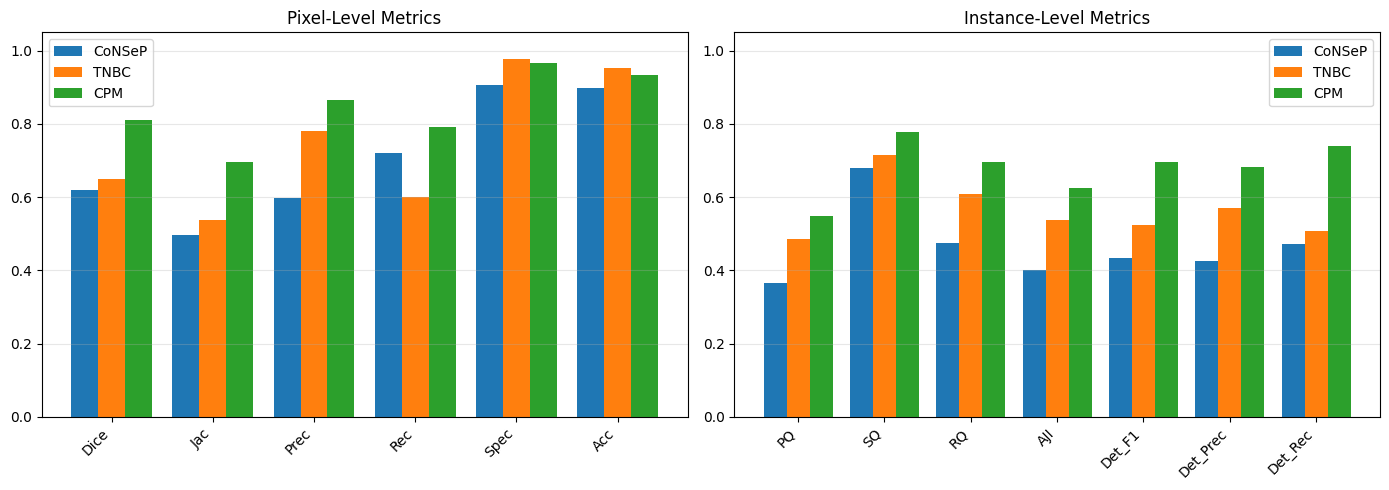


Chart saved to: /content/hovernet_test_results/comparison_chart.png


In [13]:
import matplotlib.pyplot as plt

if not all_results:
    print('No results to display!')
else:
    datasets = list(all_results.keys())

    # --- Print text table ---
    pixel_metrics_list = ['Dice', 'Jac', 'Prec', 'Rec', 'Spec', 'Acc']
    inst_metrics_list  = ['PQ', 'SQ', 'RQ', 'AJI', 'Det_F1', 'Det_Prec', 'Det_Rec']

    print('\n' + '=' * 75)
    print('  CROSS-DATASET COMPARISON: MoNuSeg-Trained HoVer-Net')
    print('=' * 75)

    # Header
    header = f'{"Metric":<14}'
    for ds in datasets:
        header += f'{ds:>12}'
    print(header)
    print('─' * (14 + 12 * len(datasets)))

    # Pixel-level section
    print('Pixel-level:')
    for metric in pixel_metrics_list:
        row = f'  {metric:<12}'
        for ds in datasets:
            val = all_results[ds].get(metric, 0.0)
            row += f'{val:>12.4f}'
        print(row)

    print()
    print('Instance-level:')
    for metric in inst_metrics_list:
        row = f'  {metric:<12}'
        for ds in datasets:
            val = all_results[ds].get(metric, 0.0)
            row += f'{val:>12.4f}'
        print(row)

    # Nuclei counts
    print()
    for metric_label, metric_key in [('Avg GT nuclei', 'N_gt'), ('Avg Pred nuclei', 'N_pred')]:
        row = f'  {metric_label:<12}'
        for ds in datasets:
            val = all_results[ds].get(metric_key, 0.0)
            row += f'{val:>12.1f}'
        print(row)

    print('=' * 75)

    # --- Bar chart ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Pixel-level metrics
    x = np.arange(len(pixel_metrics_list))
    width = 0.8 / len(datasets)
    for i, ds in enumerate(datasets):
        vals = [all_results[ds].get(m, 0) for m in pixel_metrics_list]
        axes[0].bar(x + i * width, vals, width, label=ds)
    axes[0].set_xticks(x + width * (len(datasets) - 1) / 2)
    axes[0].set_xticklabels(pixel_metrics_list, rotation=45, ha='right')
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title('Pixel-Level Metrics')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Instance-level metrics
    x = np.arange(len(inst_metrics_list))
    width = 0.8 / len(datasets)
    for i, ds in enumerate(datasets):
        vals = [all_results[ds].get(m, 0) for m in inst_metrics_list]
        axes[1].bar(x + i * width, vals, width, label=ds)
    axes[1].set_xticks(x + width * (len(datasets) - 1) / 2)
    axes[1].set_xticklabels(inst_metrics_list, rotation=45, ha='right')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title('Instance-Level Metrics')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_ROOT, 'comparison_chart.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nChart saved to: {os.path.join(OUTPUT_ROOT, "comparison_chart.png")}')


--- CoNSeP: Sample Predictions ---


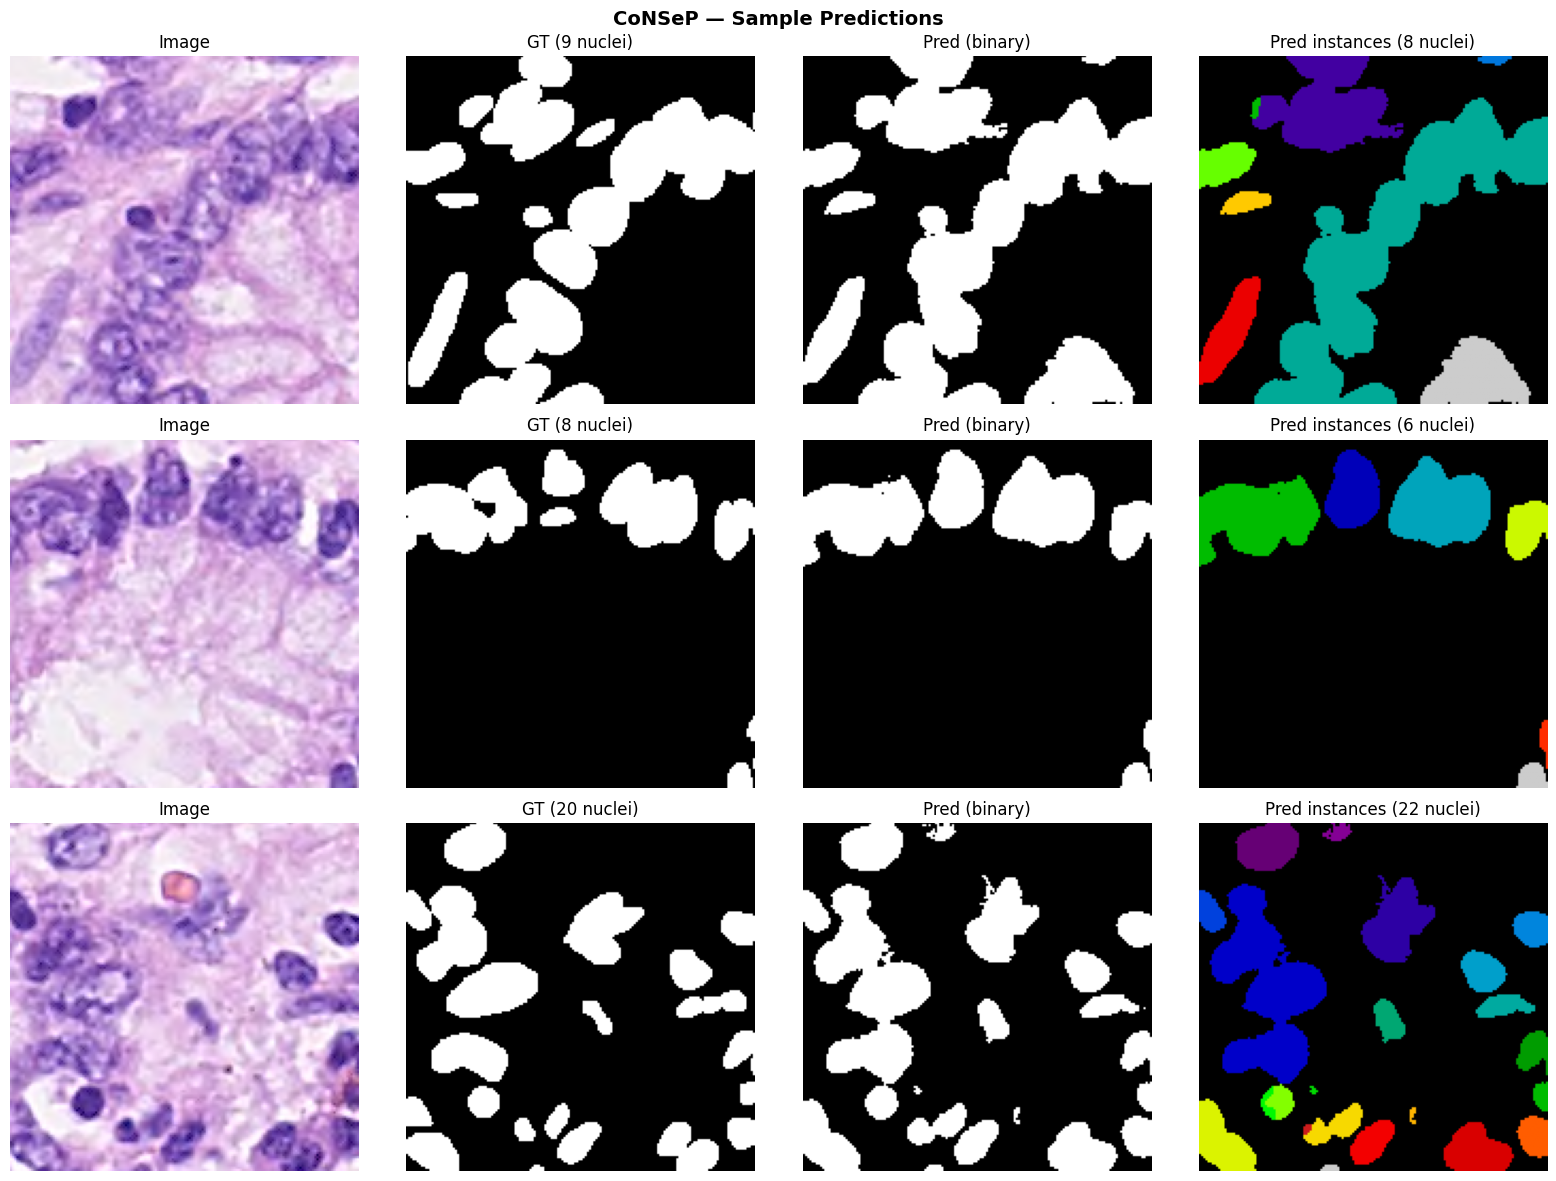


--- TNBC: Sample Predictions ---


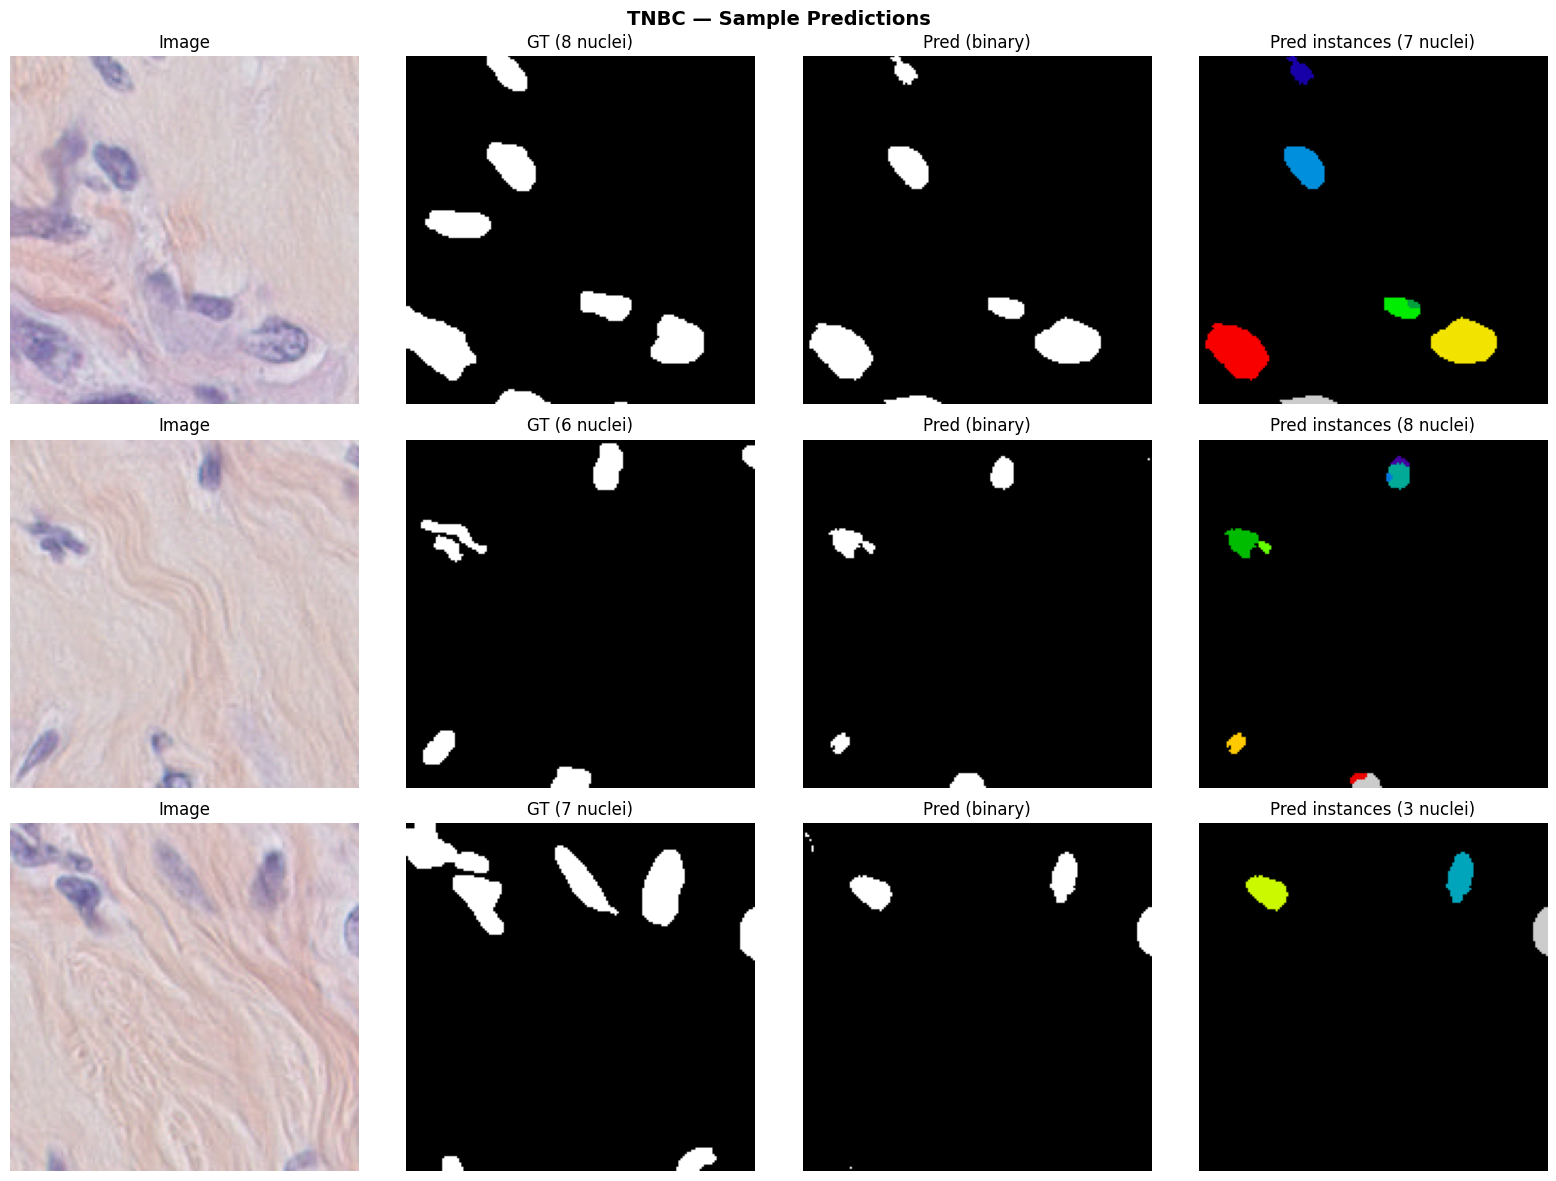


--- CPM: Sample Predictions ---


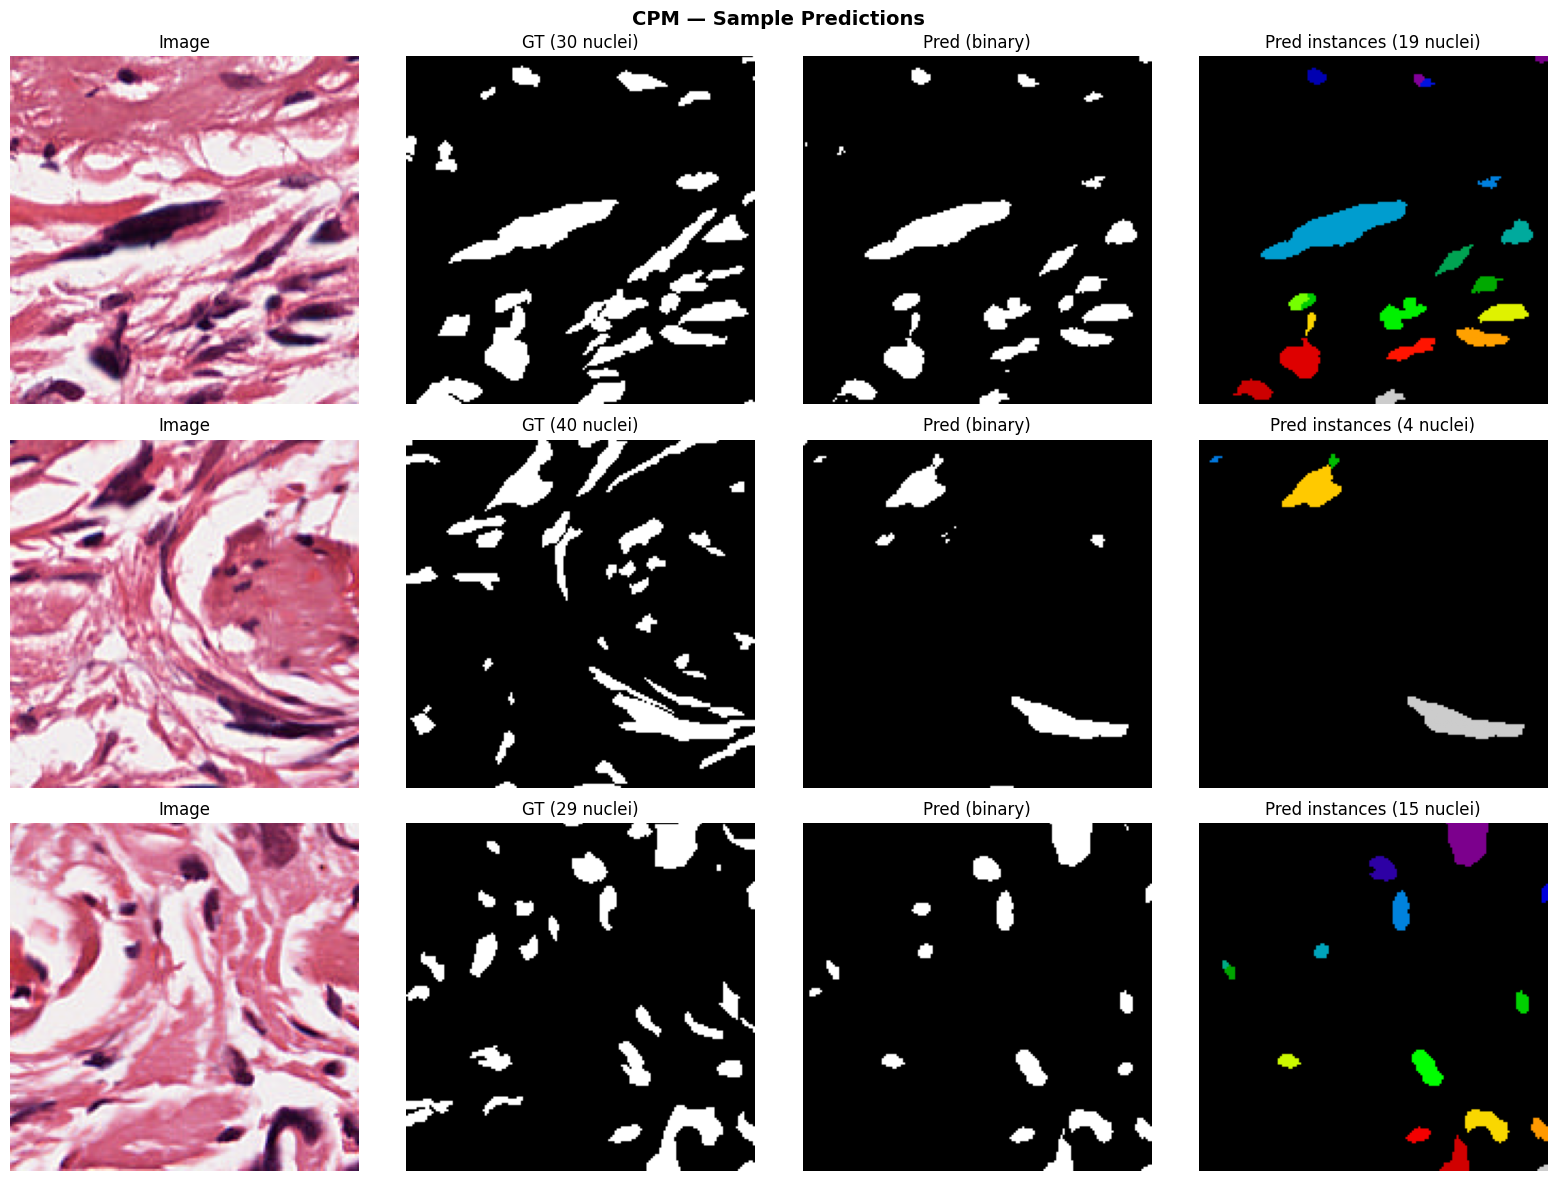

In [14]:
for name in all_results.keys():
    patch_dir = os.path.join(OUTPUT_ROOT, f'{name}_patches')
    sample_files = sorted(glob.glob(os.path.join(patch_dir, '*.npy')))[:3]

    if not sample_files:
        continue

    print(f'\n--- {name}: Sample Predictions ---')

    fig, axes = plt.subplots(len(sample_files), 4, figsize=(16, 4 * len(sample_files)))
    if len(sample_files) == 1:
        axes = [axes]

    for i, fpath in enumerate(sample_files):
        data = np.load(fpath)
        img_full = data[..., :3].astype('uint8')
        gt_inst_full = data[..., 3].astype(np.int32)

        # Run inference on this patch through the data loader
        dataset = FileLoader(
            [fpath], mode='valid', with_type=TYPE_CLASSIFICATION,
            setup_augmentor=True, input_shape=act_shape, mask_shape=out_shape,
            target_gen=(gen_targets, {})
        )
        loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
        batch = next(iter(loader))

        with torch.no_grad():
            imgs = batch['img'].permute(0, 3, 1, 2).to(device).type(torch.float32)
            output = model(imgs)
            np_probs = F.softmax(output['np'], dim=1)[0, 1].cpu().numpy()
            hv_map = output['hv'][0].permute(1, 2, 0).cpu().numpy()

        pred_binary = (np_probs > 0.5).astype(np.uint8)
        pred_inst = hovernet_post_process(np_probs, hv_map)

        # Center crop originals to match output size
        ph, pw = pred_binary.shape
        h, w = img_full.shape[:2]
        y0, x0 = (h - ph) // 2, (w - pw) // 2
        img_crop = img_full[y0:y0+ph, x0:x0+pw]
        gt_crop = gt_inst_full[y0:y0+ph, x0:x0+pw]
        gt_binary = (gt_crop > 0).astype(np.uint8)

        axes[i][0].imshow(img_crop)
        axes[i][0].set_title('Image')
        axes[i][0].axis('off')

        axes[i][1].imshow(gt_binary, cmap='gray')
        axes[i][1].set_title(f'GT ({len(np.unique(gt_crop))-1} nuclei)')
        axes[i][1].axis('off')

        axes[i][2].imshow(pred_binary, cmap='gray')
        axes[i][2].set_title('Pred (binary)')
        axes[i][2].axis('off')

        axes[i][3].imshow(pred_inst, cmap='nipy_spectral')
        axes[i][3].set_title(f'Pred instances ({pred_inst.max()} nuclei)')
        axes[i][3].axis('off')

    plt.suptitle(f'{name} — Sample Predictions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_ROOT, f'{name}_samples.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [15]:
import csv

csv_path = os.path.join(OUTPUT_ROOT, 'test_results.csv')

if all_results:
    metrics_order = ['Dice', 'Jac', 'Prec', 'Rec', 'Spec', 'Acc',
                     'PQ', 'SQ', 'RQ', 'AJI', 'Det_F1', 'Det_Prec', 'Det_Rec',
                     'N_gt', 'N_pred']

    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Dataset'] + metrics_order)
        for ds_name, results in all_results.items():
            row = [ds_name] + [f'{results.get(m, 0.0):.4f}' for m in metrics_order]
            writer.writerow(row)

    print(f'Results saved to: {csv_path}')

    # Also copy to Google Drive
    gdrive_csv = '/content/drive/MyDrive/hovernet_test_results.csv'
    shutil.copy(csv_path, gdrive_csv)
    print(f'Also saved to: {gdrive_csv}')
else:
    print('No results to save.')

Results saved to: /content/hovernet_test_results/test_results.csv
Also saved to: /content/drive/MyDrive/hovernet_test_results.csv
